<a href="https://colab.research.google.com/github/yasseen116/Software-Defect-predection-Project/blob/main/DS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("software_defect_prediction_dataset.csv")
df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [20]:
df.shape

(60000, 23)

In [21]:
# Basic description of Dataset
df.describe(include='all')

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000
mean,2530.472133,25.085650,99.900683,49.371517,0.300259,500.247800,9.465667,7.492883,150.296117,99.262667,...,102.109167,4.506767,49.991167,25.099967,0.499512,9.467117,248.720767,24.44745,14.473250,0.970383
std,1421.025394,14.112331,57.367154,28.827881,0.173254,288.724453,5.768672,4.032777,86.375771,57.774507,...,56.279245,2.866878,28.721025,14.139460,0.289559,5.746556,144.011768,14.46083,8.663821,0.169529
min,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1311.000000,13.000000,50.000000,24.000000,0.150000,251.000000,4.000000,4.000000,76.000000,49.000000,...,53.000000,2.000000,25.000000,13.000000,0.250000,4.000000,124.000000,12.00000,7.000000,1.000000
50%,2534.000000,25.000000,99.000000,49.000000,0.300000,501.000000,9.000000,7.000000,151.000000,99.000000,...,102.000000,5.000000,50.000000,25.000000,0.500000,9.000000,249.000000,24.00000,14.000000,1.000000
75%,3749.000000,37.000000,149.000000,74.000000,0.450000,750.000000,14.000000,11.000000,225.000000,149.000000,...,151.000000,7.000000,75.000000,37.000000,0.750000,14.000000,373.000000,37.00000,22.000000,1.000000
max,4999.000000,49.000000,199.000000,99.000000,0.600000,999.000000,19.000000,14.000000,299.000000,199.000000,...,199.000000,9.000000,99.000000,49.000000,1.000000,19.000000,499.000000,49.00000,29.000000,1.000000


In [17]:
#adding missing values
df.loc[df.sample(frac=0.01, random_state=42).index, 'lines_of_code'] = np.nan
df.loc[df.sample(frac=0.02, random_state=7).index, 'test_coverage'] = np.nan
df.isnull().sum()

,0
lines_of_code,600
cyclomatic_complexity,0
num_functions,0
num_classes,0
comment_density,0
code_churn,0
developer_experience_years,0
num_developers,0
commit_frequency,0
bug_fix_commits,0


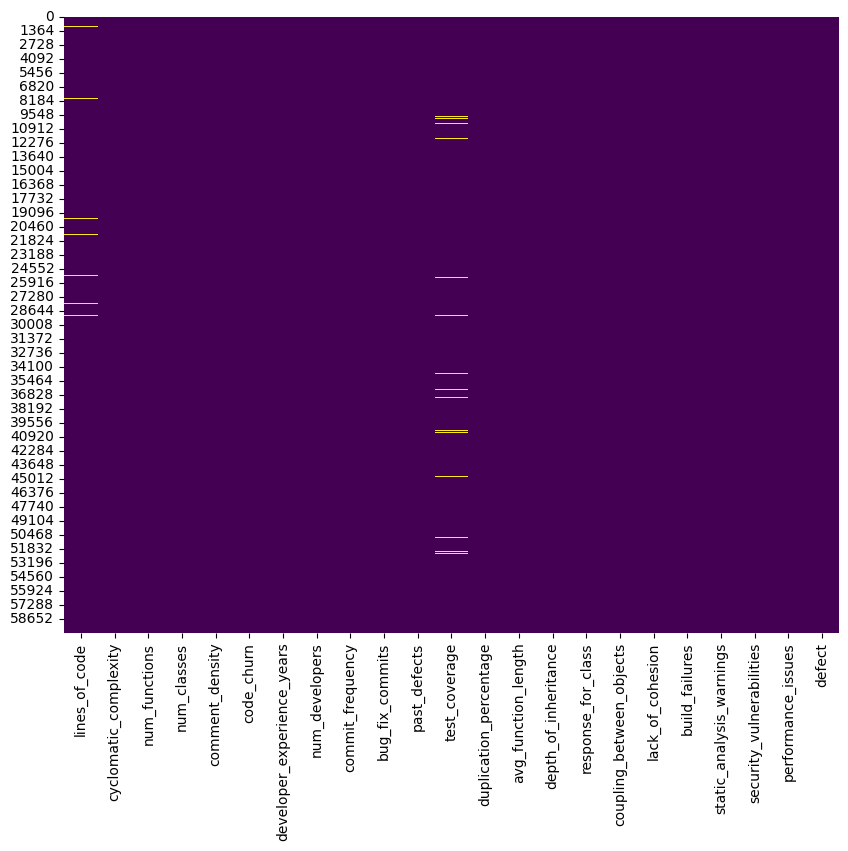

In [18]:
plt.figure(figsize= (10,8))
#heatmap of missing values
sns.heatmap(df.isnull(),cbar= False,cmap="viridis")
plt.show()


In [46]:
#removing missing values
df["cyclomatic_complexity"].fillna(
    df["cyclomatic_complexity"].median(),
    inplace=True
)
df["lines_of_code"].fillna(
    df["lines_of_code"].median(),
    inplace=True
)
df["num_functions"].fillna(
    df["num_functions"].median(),
    inplace=True
)
df["comment_density"].fillna(
    df["comment_density"].median(),
    inplace=True
)
df["developer_experience_years"].fillna(
    df["developer_experience_years"].median(),
    inplace=True
)
df["test_coverage"].fillna(
    df["test_coverage"].median(),
    inplace=True
)
df["duplication_percentage"].fillna(
    df["duplication_percentage"].median(),
    inplace=True
)
df["defect"].fillna(
    df["defect"].median(),
    inplace=True
)
df.isnull().sum()


/tmp/ipykernel_7262/2160188245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cyclomatic_complexity"].fillna(
/tmp/ipykernel_7262/2160188245.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

,0
lines_of_code,0
cyclomatic_complexity,0
num_functions,0
num_classes,0
comment_density,0
code_churn,0
developer_experience_years,0
num_developers,0
commit_frequency,0
bug_fix_commits,0


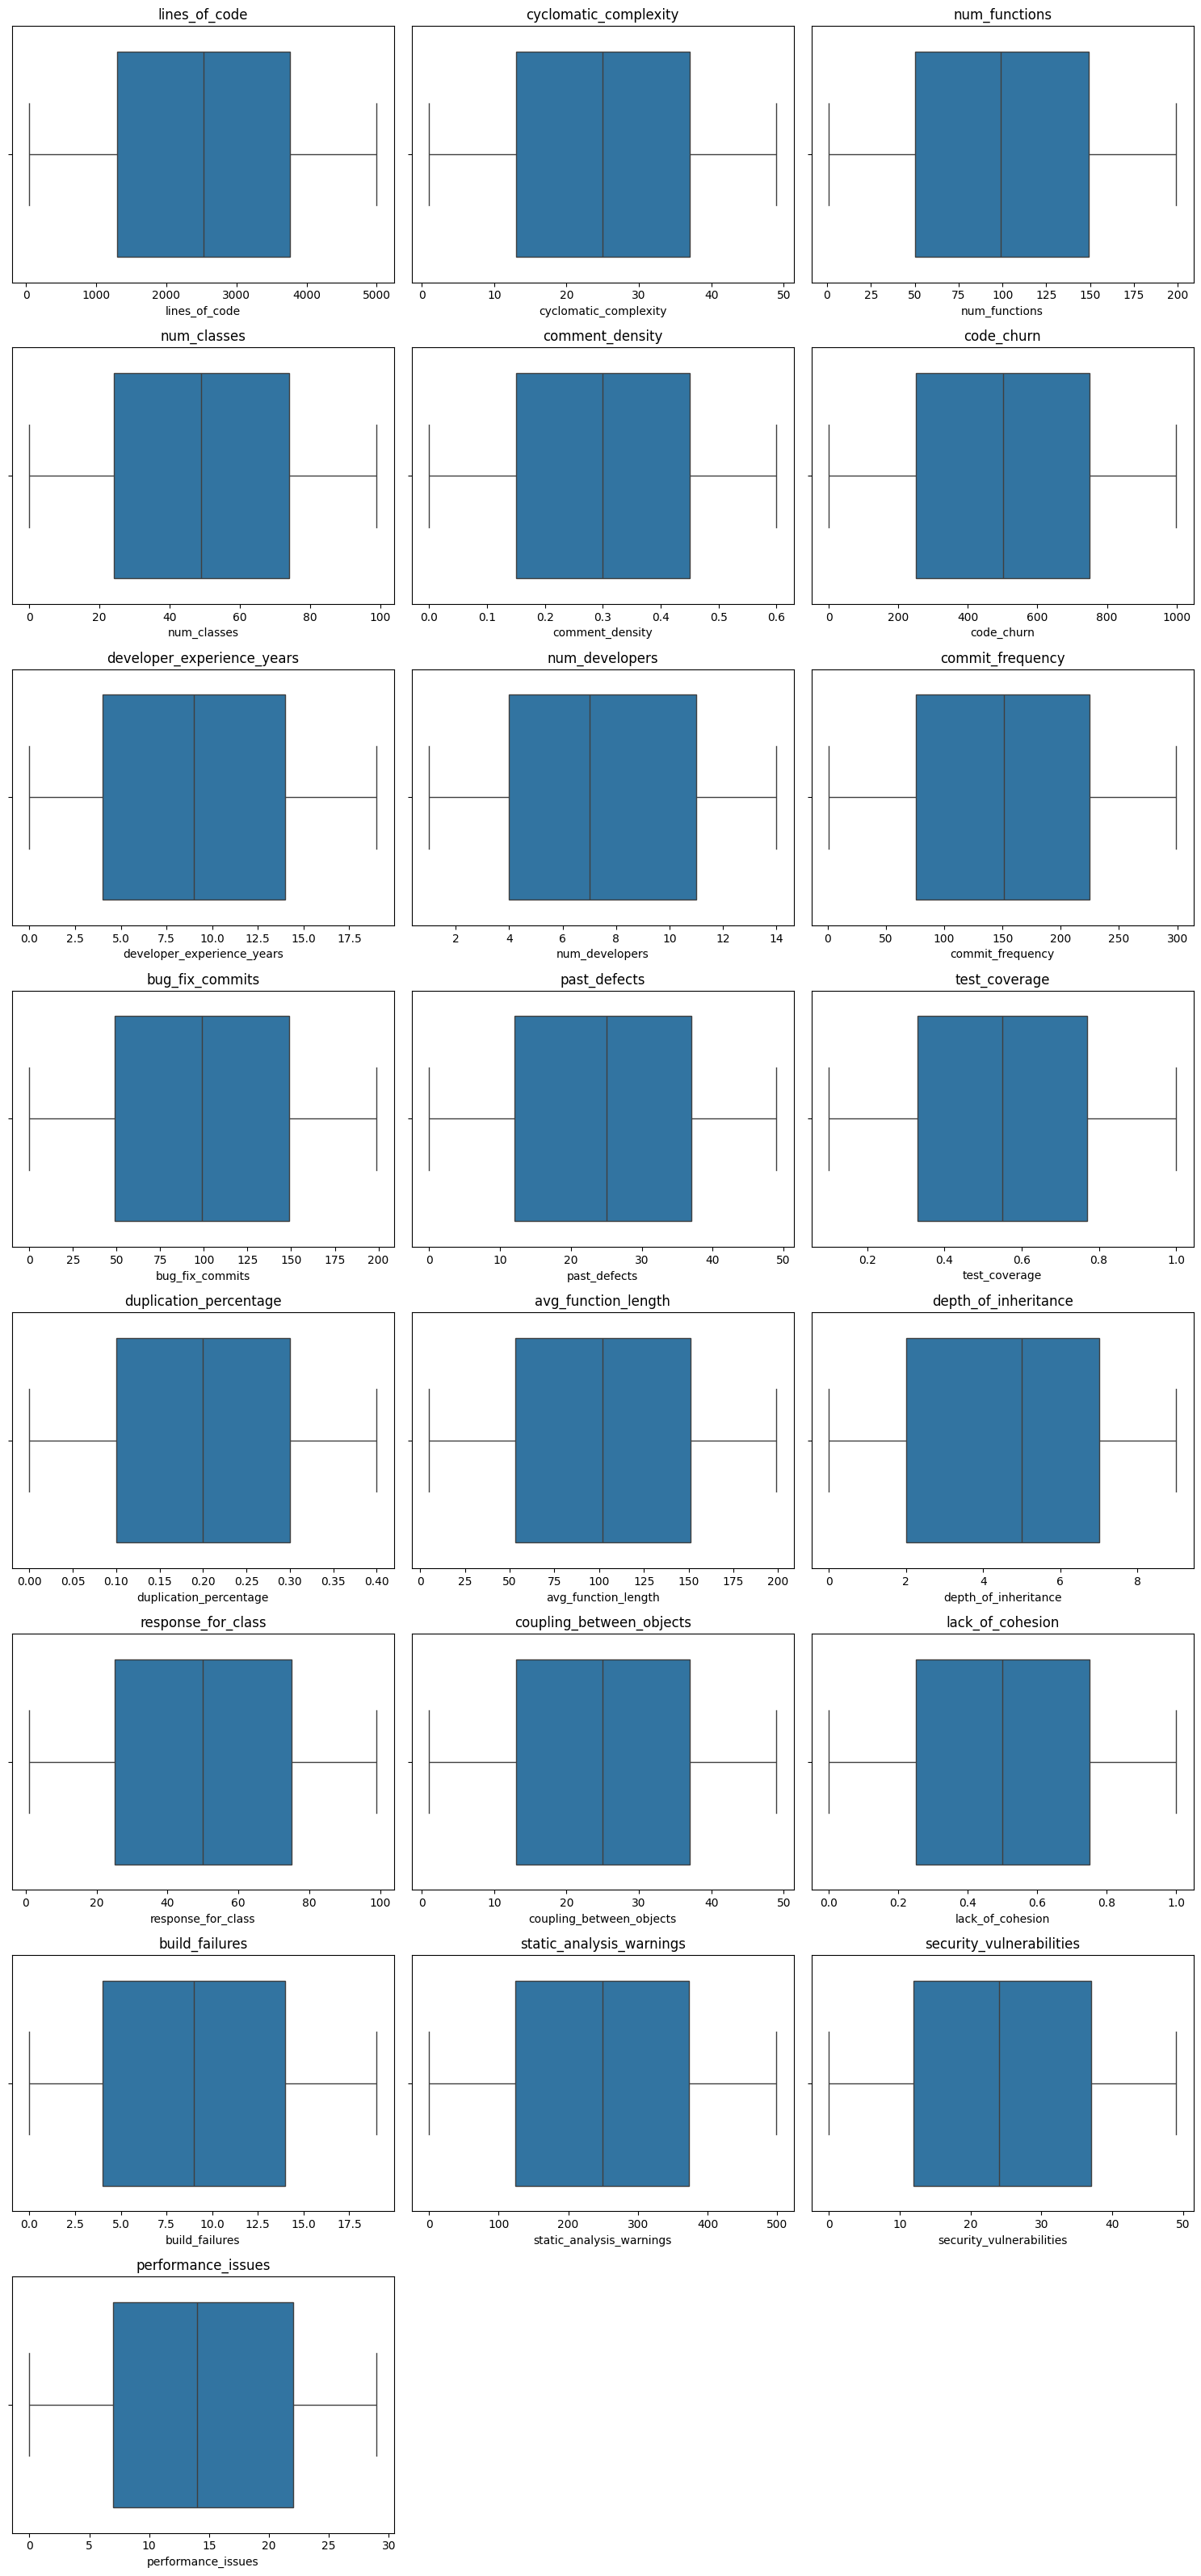

In [57]:
# BOXPLOTS FOR ALL NUMERIC COLUMNS (checking for outliers)

cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns if col != "defect"]

n_cols = 3  # number of plots per row
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7262/246351391.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '109.75963893125355' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_outliers.loc[indices, col] = df_outliers[col].mean() + 6 * df_outliers[col].std()


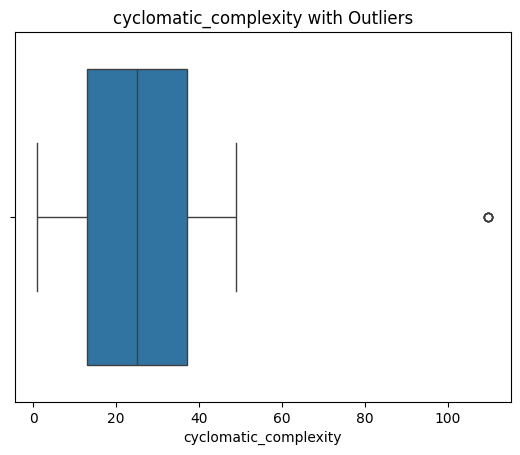

In [56]:
# ADD OUTLIERS TO ONE COLUMN

import numpy as np

df_outliers = df.copy()
col = "cyclomatic_complexity"

# Add 5 extreme high values
indices = np.random.choice(df_outliers.index, size=5, replace=False)

df_outliers.loc[indices, col] = df_outliers[col].mean() + 6 * df_outliers[col].std()

# Plot
sns.boxplot(x=df_outliers[col])
plt.title(f"{col} with Outliers")
plt.show()

Outliers fixed!


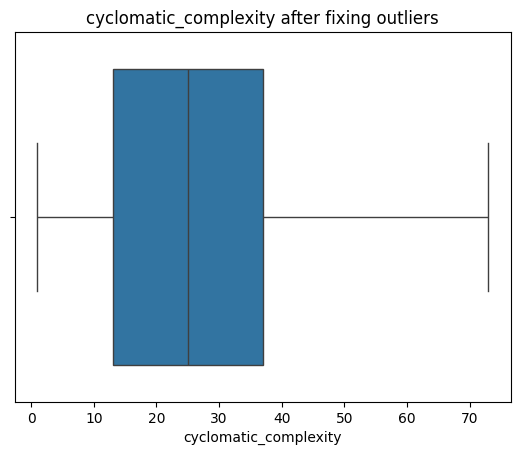

In [55]:
# FIX OUTLIERS USING IQR (CLIPPING)

df_fixed = df_outliers.copy()

# Calculate IQR
Q1 = df_fixed[col].quantile(0.25)
Q3 = df_fixed[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Clip values
df_fixed[col] = df_fixed[col].clip(lower, upper)

print("Outliers fixed!")

# Plot after fixing
sns.boxplot(x=df_fixed[col])
plt.title(f"{col} after fixing outliers")
plt.show()

In [58]:
#amount of duplicates
print(df.duplicated().sum())


0


In [59]:
## scaling dataset
# Separate features and target
X = df.drop("defect", axis=1)
y = df["defect"]

# Scale ONLY numerical features in X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=["int64", "float64"]))

# Put scaled data back into X
X[X.select_dtypes(include=["int64", "float64"]).columns] = X_scaled

# Combine back
df = pd.concat([X, y], axis=1)

df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,-1.134527,-0.927257,-1.619419,1.027780,1.672362,0.134220,1.652792,-0.866131,-1.473760,-1.596958,...,-0.570538,-1.223211,0.139580,0.134379,-1.517877,-1.125399,-1.588222,0.453128,0.753340,1
1,0.904378,-1.139839,1.692608,0.784958,-0.001497,0.290079,-0.254076,0.125750,-0.281286,0.930130,...,1.384018,0.172047,0.801121,-0.148519,-0.378205,-0.081287,-0.657735,0.937198,1.676728,1
2,0.428260,-0.360372,-0.015700,1.478736,-1.098163,0.321251,-1.640888,-0.370191,1.409017,1.345541,...,0.886495,0.172047,-1.427230,0.417278,-1.448806,-0.429325,1.224072,-0.169248,-0.978012,1
3,-1.410395,0.985979,-0.834991,1.027780,-0.694128,-1.452081,0.439331,1.613571,-1.554802,-1.718119,...,1.010875,1.567304,-0.939778,-0.926491,-0.205528,-1.299418,0.626893,-0.030942,-0.285471,1
4,1.362292,0.135652,1.082498,0.889025,-0.520970,1.446901,0.786034,-1.610041,0.158656,0.168542,...,1.188562,-0.874396,1.184119,-1.138664,-0.309134,-1.125399,-0.956324,-0.376707,-1.439706,1


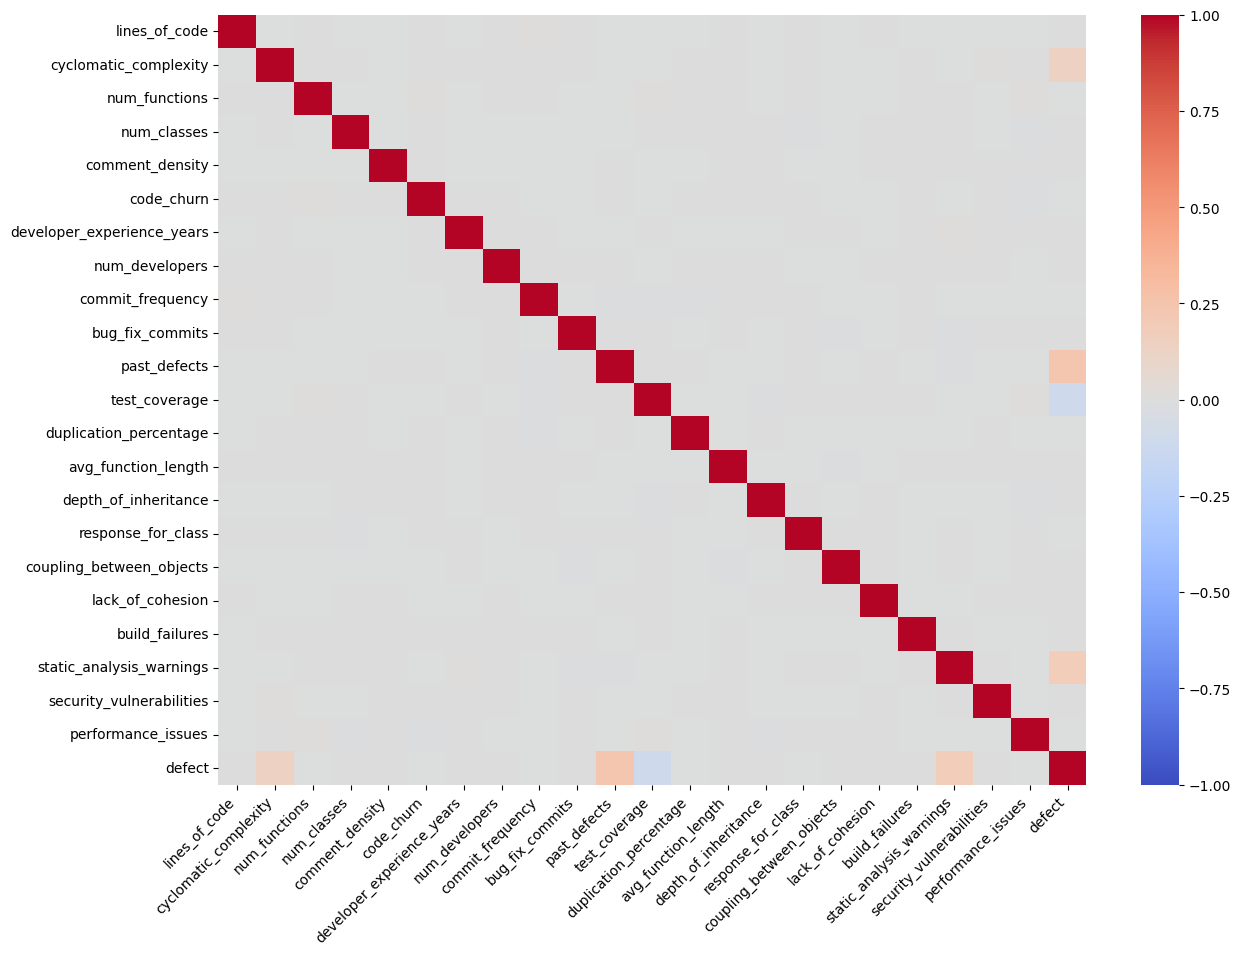

In [60]:
#correlation
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("defect", axis=1)
y = df["defect"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

past_defects                  0.302213
static_analysis_warnings      0.245046
cyclomatic_complexity         0.185898
test_coverage                 0.137319
lines_of_code                 0.009315
bug_fix_commits               0.008709
code_churn                    0.008544
commit_frequency              0.008044
num_functions                 0.008001
avg_function_length           0.007928
response_for_class            0.007882
lack_of_cohesion              0.007709
num_classes                   0.007703
security_vulnerabilities      0.007165
comment_density               0.007065
duplication_percentage        0.006921
coupling_between_objects      0.006802
performance_issues            0.006613
build_failures                0.005923
developer_experience_years    0.005895
num_developers                0.004944
depth_of_inheritance          0.004360
dtype: float64


In [68]:
# Select features based on the importance values you already got
selected_features = importances[importances > 0.01].index

# Create a new dataset with only the selected features and the target column
df_selected = df[selected_features.tolist() + ["defect"]]

# Show the selected features and the new dataset shape
print("Selected features:", list(selected_features))
print("Original shape:", df.shape)
print("Reduced shape:", df_selected.shape)

df_selected.head()

Selected features: ['cyclomatic_complexity', 'past_defects', 'test_coverage', 'static_analysis_warnings']
Original shape: (60000, 23)
Reduced shape: (60000, 5)


,cyclomatic_complexity,past_defects,test_coverage,static_analysis_warnings,defect
0,-0.927257,-0.105392,-0.810850,-1.588222,1
1,-1.139839,-0.382540,-1.196959,-0.657735,1
2,-0.360372,-1.560419,-0.386129,1.224072,1
3,0.985979,1.488209,1.042475,0.626893,1
4,0.135652,0.310330,-0.347518,-0.956324,1


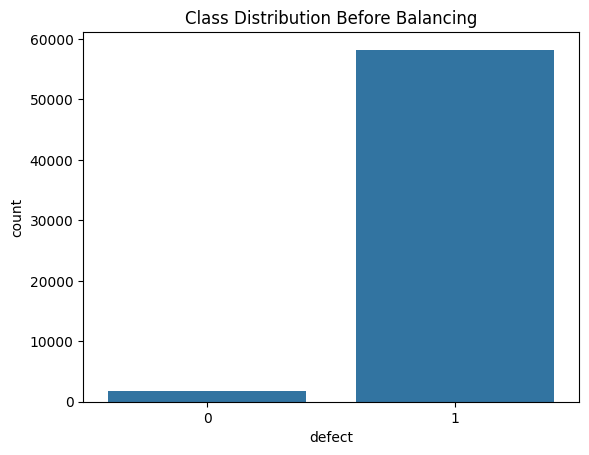

In [77]:
# Plot the class distribution before balancing
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="defect", data=df_selected)
plt.title("Class Distribution Before Balancing")
plt.show()

In [78]:
# Balance the dataset by oversampling the minority class
from sklearn.utils import resample
import pandas as pd

df_majority = df_selected[df_selected["defect"] == 1]
df_minority = df_selected[df_selected["defect"] == 0]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1, random_state=42)

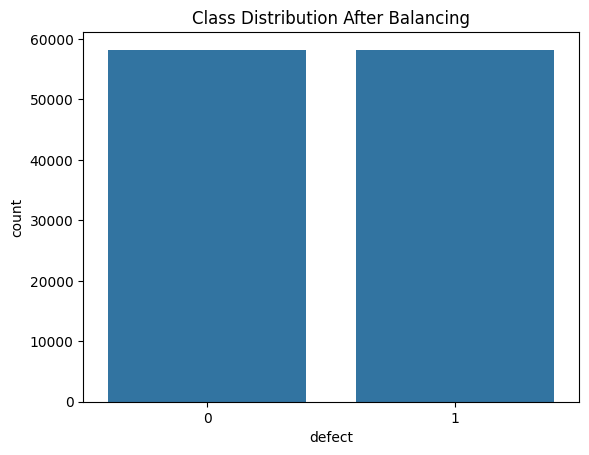

In [79]:
# Plot the class distribution after balancing
sns.countplot(x="defect", data=df_balanced)
plt.title("Class Distribution After Balancing")
plt.show()

In [82]:
# Import Decision Tree and evaluation tools
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split balanced features and target
X = df_balanced.drop("defect", axis=1)
y = df_balanced["defect"]

# Split data into training and testing sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict target values for the test set
y_pred = dt_model.predict(X_test)

# Print model evaluation results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[11645     0]
 [    0 11645]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11645
           1       1.00      1.00      1.00     11645

    accuracy                           1.00     23290
   macro avg       1.00      1.00      1.00     23290
weighted avg       1.00      1.00      1.00     23290

